# ACTIVITY 1: IMDB SENTIMENT CLASSIFICATION

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import tiktoken

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Load Dataset

In [4]:
import pandas as pd

df = pd.read_csv(
    "IMDB Dataset.csv",
    encoding="utf-8",
    engine="python",
    on_bad_lines="skip"
)

print("Rows loaded:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment:")
print(df["sentiment"].value_counts())

Rows loaded: 50000

Columns:
['review', 'sentiment']

Missing values:
review       0
sentiment    0
dtype: int64

Sentiment:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [5]:
# Remove missing values and duplicate reviews

df = df.dropna(subset=["review", "sentiment"])
df = df.drop_duplicates(subset=["review"]).reset_index(drop=True)

print("Total usable reviews:", len(df))
print(df["sentiment"].value_counts())

Total usable reviews: 49582
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


In [6]:
# Use 95% of the available dataset

df = df.sample(frac=0.95, random_state=42).reset_index(drop=True)

print("Reviews used (95%):", len(df))

Reviews used (95%): 47103


Convert sentiment to numbers

In [7]:
df["sentiment"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

print(df["sentiment"].value_counts())

sentiment
1    23691
0    23412
Name: count, dtype: int64


Train/Test split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["review"].values,
    df["sentiment"].values,
    test_size=0.05,
    random_state=42,
    stratify=df["sentiment"].values
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 44747
Testing samples: 2356


Import tiktoken

In [9]:
import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")

print("Tokenizer loaded successfully")
print("Vocabulary size:", encoding.n_vocab)

Tokenizer loaded successfully
Vocabulary size: 100277


Tokenization + Padding

In [10]:
MAX_LEN = 200
PAD_ID = 0

def tokenize_and_pad(texts):
    data = []

    for text in texts:
        tokens = encoding.encode(text)

        # Truncate
        tokens = tokens[:MAX_LEN]

        # Shift IDs by 1 because 0 is used for padding
        tokens = [token + 1 for token in tokens]

        # Pad
        tokens += [PAD_ID] * (MAX_LEN - len(tokens))

        data.append(tokens)

    return torch.tensor(data, dtype=torch.long)

Tokenize train and test data

In [11]:
import torch

X_train_tensor = tokenize_and_pad(X_train)
X_test_tensor = tokenize_and_pad(X_test)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("X_train:", X_train_tensor.shape)
print("X_test :", X_test_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("y_test :", y_test_tensor.shape)

X_train: torch.Size([44747, 200])
X_test : torch.Size([2356, 200])
y_train: torch.Size([44747])
y_test : torch.Size([2356])


Create DataLoaders

In [12]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("DataLoaders created successfully")

DataLoaders created successfully


In [13]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

Using: cuda


Build the Improved RNN

In [14]:
import torch.nn as nn

class RNNClassifier(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            128,
            padding_idx=PAD_ID
        )

        self.rnn = nn.RNN(
            input_size=128,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.4)

        self.fc = nn.Linear(
            128 * 2,
            2
        )

    def forward(self, x):

        x = self.embedding(x)

        output, hidden = self.rnn(x)

        # Use final timestep
        x = output[:, -1, :]

        x = self.dropout(x)

        return self.fc(x)

Create Model

In [15]:
VOCAB_SIZE = encoding.n_vocab + 1

model = RNNClassifier(
    VOCAB_SIZE
).to(device)

print(model)

RNNClassifier(
  (embedding): Embedding(100278, 128, padding_idx=0)
  (rnn): RNN(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


Loss and Optimizer

In [16]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("Loss and optimizer ready")

Loss and optimizer ready


Train the RNN

In [17]:
EPOCHS = 8

best_loss = float("inf")
patience = 2
counter = 0

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        output = model(batch_x)

        loss = criterion(output, batch_y)

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"- Loss: {avg_loss:.4f}"
    )

    # Save best model
    if avg_loss < best_loss:

        best_loss = avg_loss
        counter = 0

        torch.save(
            model.state_dict(),
            "best_rnn_model.pth"
        )

    else:

        counter += 1

        if counter >= patience:

            print("Early stopping...")
            break

Epoch 1/8 - Loss: 0.6996
Epoch 2/8 - Loss: 0.6924
Epoch 3/8 - Loss: 0.6888
Epoch 4/8 - Loss: 0.6871
Epoch 5/8 - Loss: 0.6837
Epoch 6/8 - Loss: 0.6643
Epoch 7/8 - Loss: 0.6365
Epoch 8/8 - Loss: 0.6225


Load Best Model

In [18]:
model.load_state_dict(
    torch.load(
        "best_rnn_model.pth",
        map_location=device
    )
)

model.eval()

print("Best RNN model loaded")

Best RNN model loaded


Make Test Predictions

In [19]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for batch_x, batch_y in test_loader:

        batch_x = batch_x.to(device)

        output = model(batch_x)

        predictions = torch.argmax(
            output,
            dim=1
        ).cpu().numpy()

        all_predictions.extend(predictions)
        all_labels.extend(batch_y.numpy())

print("Predictions completed")

Predictions completed


Accuracy, Precision, Recall, F1

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions
)

recall = recall_score(
    all_labels,
    all_predictions
)

f1 = f1_score(
    all_labels,
    all_predictions
)

print("========== RNN RESULTS ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

========== RNN RESULTS ==========
Accuracy : 0.6222
Precision: 0.6279
Recall   : 0.6110
F1 Score : 0.6193


Classification Report

In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.62      0.63      0.63      1171
    Positive       0.63      0.61      0.62      1185

    accuracy                           0.62      2356
   macro avg       0.62      0.62      0.62      2356
weighted avg       0.62      0.62      0.62      2356



Confusion Matrix

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[742 429]
 [461 724]]


Visualize Confusion Matrix

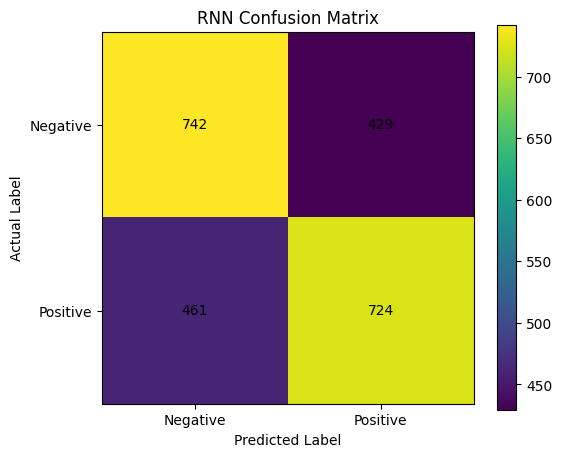

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.yticks(
    [0, 1],
    ["Negative", "Positive"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

Custom Reviews

In [24]:
new_reviews = [
    "This movie was absolutely fantastic and I loved every minute of it.",
    "The movie was boring, predictable and a complete waste of time.",
    "The acting was excellent and the story was very enjoyable."
]

Prediction Function

In [25]:
def predict_sentiment(text):

    tokens = encoding.encode(text)

    tokens = tokens[:MAX_LEN]

    tokens = [token + 1 for token in tokens]

    tokens += [PAD_ID] * (
        MAX_LEN - len(tokens)
    )

    tensor = torch.tensor(
        [tokens],
        dtype=torch.long
    ).to(device)

    model.eval()

    with torch.no_grad():

        output = model(tensor)

        prediction = torch.argmax(
            output,
            dim=1
        ).item()

    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

Test Custom Reviews

In [26]:
print("====== CUSTOM REVIEW PREDICTIONS ======")

for review in new_reviews:

    prediction = predict_sentiment(review)

    print("\nReview:", review)
    print("Predicted Sentiment:", prediction)

====== CUSTOM REVIEW PREDICTIONS ======

Review: This movie was absolutely fantastic and I loved every minute of it.
Predicted Sentiment: Positive

Review: The movie was boring, predictable and a complete waste of time.
Predicted Sentiment: Negative

Review: The acting was excellent and the story was very enjoyable.
Predicted Sentiment: Negative
